## Cell 1: setup

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT / "eval"))

from pipeline import predict_relative_depth
from pipeline.segmentation import remap_dfc_labels, CLASS_NAMES
import metrics as M

RAW = ROOT / "data" / "raw" / "dfc2019"
N_TILES = 20   # raise later for a more reliable estimate

## Cell 2: tile loading

In [2]:
def find_tiles():
    tiles = []
    for rgb in sorted(RAW.rglob("*_RGB.tif")):
        base = rgb.name[:-len("_RGB.tif")]
        agl = next(RAW.rglob(f"{base}_AGL.tif"), None)
        cls = next(RAW.rglob(f"{base}_CLS.tif"), None)
        if agl and cls:
            tiles.append((base, rgb, agl, cls))
    return tiles

def read_rgb(path):
    with rasterio.open(path) as src:
        arr = src.read([1, 2, 3]).transpose(1, 2, 0).astype(np.float32)
    if arr.max() > 255:
        lo, hi = np.percentile(arr, (2, 98))
        arr = np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1) * 255
    return Image.fromarray(arr.astype(np.uint8))

def read_band(path):
    with rasterio.open(path) as src:
        return src.read(1)

tiles = find_tiles()
print(len(tiles), "complete tiles")
idx = np.linspace(0, len(tiles) - 1, N_TILES).astype(int)   # evenly spread, reproducible
sample = [tiles[i] for i in idx]

2783 complete tiles


## Cell 3: run the backbone on the sample

In [3]:
rows, cache = [], {}
for name, rgb_p, agl_p, cls_p in sample:
    img = read_rgb(rgb_p)
    depth = predict_relative_depth(img)
    agl = read_band(agl_p).astype(np.float32)
    labels = remap_dfc_labels(read_band(cls_p))

    raw = M.compute_metrics(depth, agl)                     # raw corr = direction + shape
    aligned, a, b = M.affine_align(depth, agl, mask=labels != 255)
    glob = M.compute_metrics(aligned, agl, mask=labels != 255)
    cls_corr = {k: v["corr"] for k, v in M.per_class_metrics(depth, agl, labels, CLASS_NAMES).items()}

    rows.append({"tile": name, "raw_corr": raw["corr"], "global_rmse": glob["rmse"],
                 "global_mae": glob["mae"], "scale": a, "shift": b, **{f"corr_{k}": v for k, v in cls_corr.items()}})
    cache[name] = (img, depth, agl)

df = pd.DataFrame(rows)
df

/home/tanmay/Projects/depthWizard/depthWizard/.venv/lib/python3.14/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

,tile,raw_corr,global_rmse,global_mae,scale,shift,corr_ground,corr_vegetation,corr_building,corr_water,corr_ignore
0,JAX_004_006,0.524215,4.449540,3.309524,15.842534,-1.242571,0.128408,0.328411,0.101700,0.056914,NaN
1,JAX_079_009,0.651928,2.964398,2.191116,14.437459,-1.887918,0.374831,0.564298,0.594202,NaN,NaN
2,JAX_156_008,0.864906,1.882748,1.322143,11.220934,-1.313300,0.183917,0.230481,0.691287,NaN,NaN
3,JAX_167_025,0.510404,26.054222,14.627723,77.509177,-8.597079,0.208055,0.341906,0.315483,0.118329,NaN
4,JAX_207_015,0.535339,5.028281,3.800940,15.026991,0.336672,0.838379,0.262390,0.612617,0.065256,NaN
5,JAX_264_026,0.731923,3.546073,2.384295,16.955713,-2.100542,0.519351,0.288661,0.630956,-0.261065,NaN
6,JAX_416_007,0.711205,2.811586,1.923880,11.173302,-0.095022,0.183634,0.399625,0.738268,0.539719,NaN
7,OMA_042_010,0.316399,3.965264,3.175376,8.657407,1.640184,0.144976,0.195538,0.336879,0.890577,NaN
8,OMA_129_021,0.233258,5.132069,3.903476,5.780143,-0.978453,0.060809,0.140612,NaN,0.254483,NaN
9,OMA_144_030,0.097628,0.028393,0.021748,0.015689,-0.007068,0.097628,NaN,NaN,NaN,NaN


## Cell 4 : Summary

In [4]:
print("Mean raw correlation:        ", round(df.raw_corr.mean(), 3))
print("Tiles with NEGATIVE corr:    ", int((df.raw_corr < 0).sum()), "of", len(df))
print("Global-fit RMSE (m): mean", round(df.global_rmse.mean(), 2), " median", round(df.global_rmse.median(), 2))
print("Scale spread across tiles:   ", round(df.scale.std() / abs(df.scale.mean()), 2), "(relative std)")
df.filter(like="corr_").mean().round(3)

Mean raw correlation:         0.512
Tiles with NEGATIVE corr:     0 of 20
Global-fit RMSE (m): mean 4.01  median 3.02
Scale spread across tiles:    1.16 (relative std)


corr_ground        0.216
corr_vegetation    0.179
corr_building      0.431
corr_water         0.161
corr_ignore          NaN
dtype: float64

## Cell 5: visual check of 3 tiles

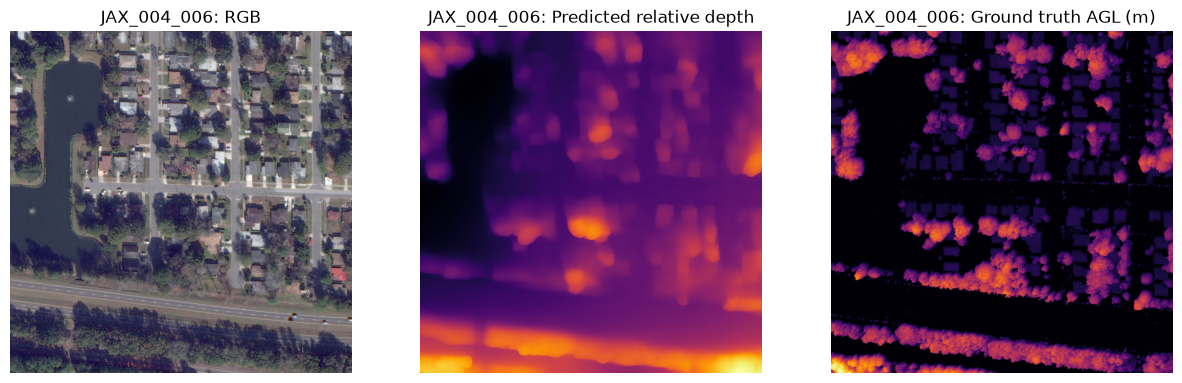

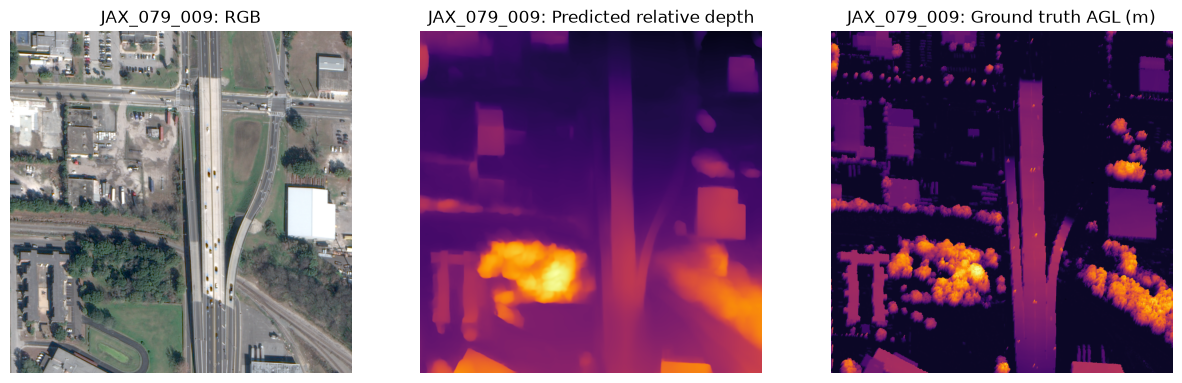

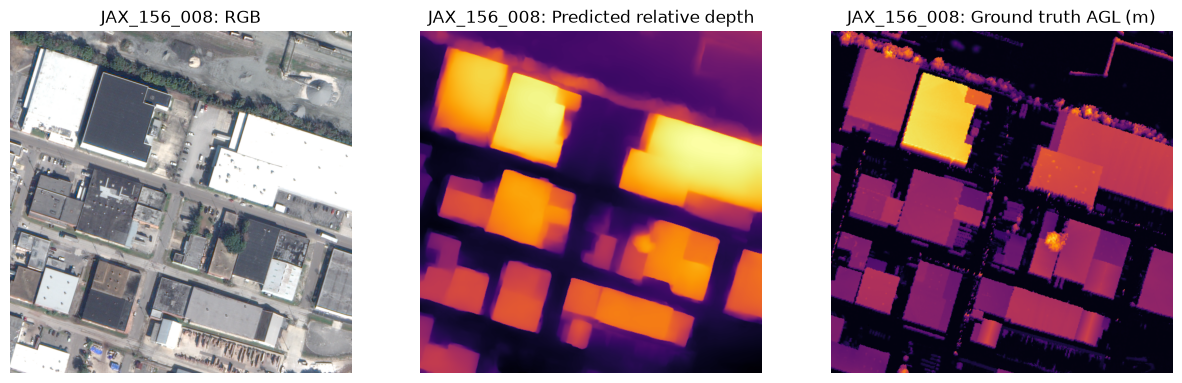

In [5]:
for name in list(cache)[:3]:
    img, depth, agl = cache[name]
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img); ax[1].imshow(depth, cmap="inferno"); ax[2].imshow(agl, cmap="inferno")
    for a_, t in zip(ax, ["RGB", "Predicted relative depth", "Ground truth AGL (m)"]):
        a_.set_title(f"{name}: {t}"); a_.axis("off")
    plt.show()